# 一括処理 - 画像の読み込みから輪郭抽出／ブロブ分析まで

## 1. 関数定義

In [1]:
# 画像の切り出し関数
import numpy as np
import cv2

def crop_image(image: np.ndarray, left: int, top: int, width: int = 400, height: int = 400) -> np.ndarray:
    """画像を切り取る関数

    Args:
        image (np.ndarray): 切り取る対象の画像
        left (int): 切り取る領域の左端のx座標
        top (int): 切り取る領域の上端のy座標
        width (int): 切り取る領域の幅
        height (int): 切り取る領域の高さ

    Returns:
        np.ndarray: 切り取られた画像
    """

    cropped_image = image[top:top+height, left:left+width]  # 終点は含まない
    return cropped_image

In [2]:
# 大津の二値化関数
import cv2

def binarize_image_with_otsu_algorithm(image: np.ndarray) -> np.ndarray:
    """画像を読み込み、グレースケール変換、二値化して表示する関数
    Args:
        image (np.ndarray): 画像の配列
    
    Returns:
        binary_image (numpy.ndarray): 二値化された画像
    """

    blur = cv2.GaussianBlur(image,(5,5),0)  # ガウシアンブラーでノイズを減らす
    gray_image = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)  # グレースケール変換
    ret, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # 大津の二値化
    return binary_image

In [3]:
# 輪郭分析
import cv2

def analyze_contours(binary_image: np.ndarray) -> list:
    """二値化された画像から輪郭を検出し、輪郭のリストを返す関数

    Args:
        binary_image (np.ndarray): 二値化された画像の配列
    
    Returns:
        contours (list): 検出された輪郭のリスト
    """

    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    contour_areas = [cv2.contourArea(contour) for contour in contours]
    # 面積が1000以上10000未満の輪郭を残す
    filtered_contours = [contour for contour in contours if 1000 < cv2.contourArea(contour) < 10000]
    
    return filtered_contours

In [4]:
# ブロブ分析
import cv2

def analyze_blobs(binary_image: np.ndarray) -> list:
    """二値化された画像からブロブを検出し、ブロブのリストを返す関数

    Args:
        binary_image (np.ndarray): 二値化された画像の配列
    
    Returns:
        blobs (list): 検出されたブロブのリスト
    """

    filtered_stats = []
    filtered_centroids = []
    retval, labeled_image, stats, centroids = cv2.connectedComponentsWithStats(binary_image, connectivity=8)
    for i in range(0, retval):
        if not (1000 < (area := stats[i][4]) < 10000):  # 面積が1000以下または10000以上のブロブは無視
            continue
        filtered_stats.append(stats[i])
        filtered_centroids.append(centroids[i])

    return (filtered_stats, filtered_centroids)

## 2. 画像の読み込み

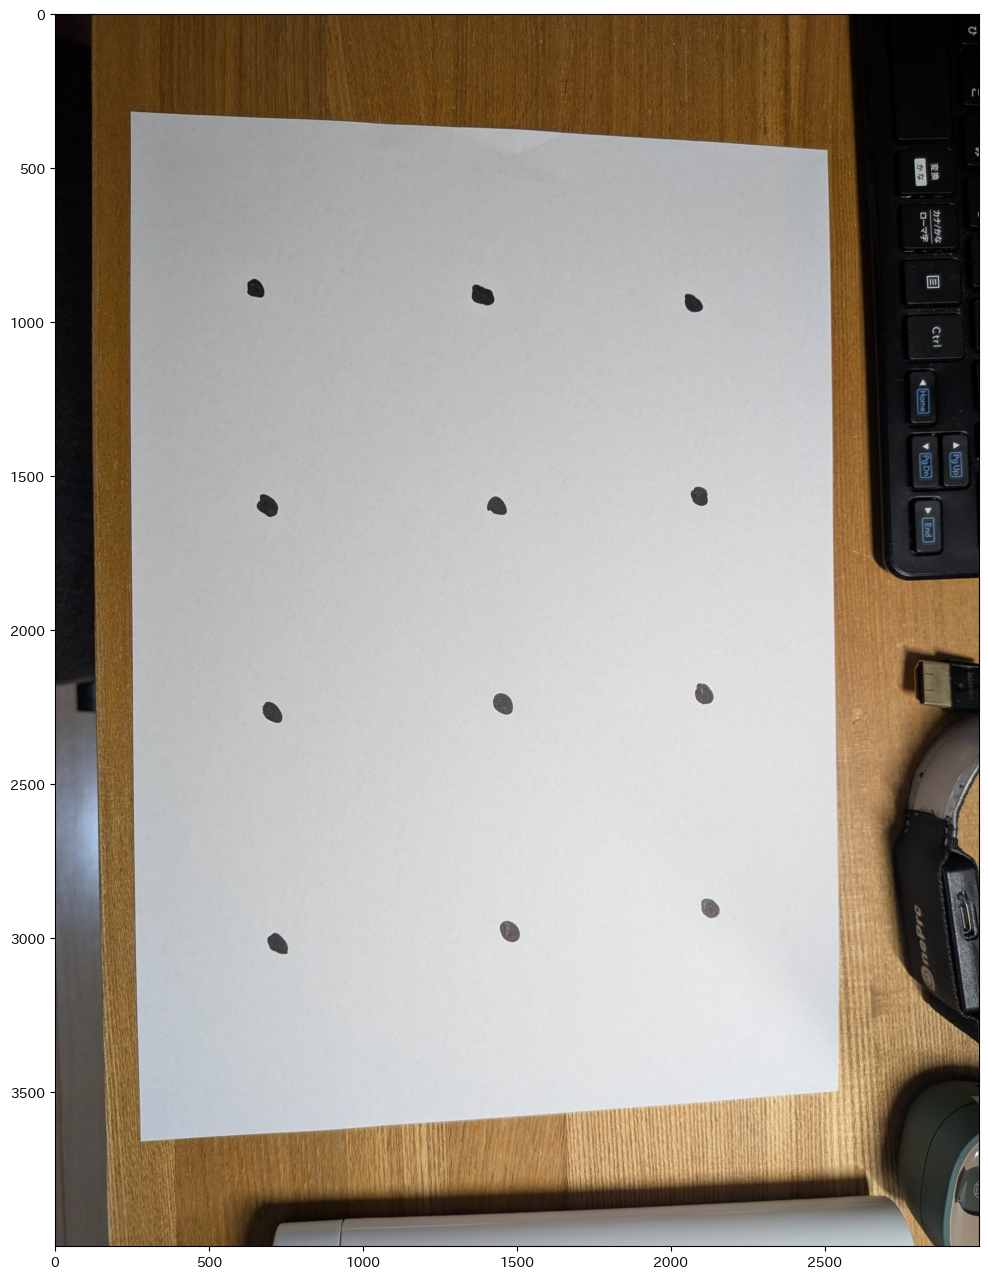

In [5]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('data/multi_dot_image1.jpg')  # 読み込み
plt.figure(figsize=(20, 16)) 
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # 表示。BGR -> RGBへ変換
plt.show()

## 3. バッチ処理

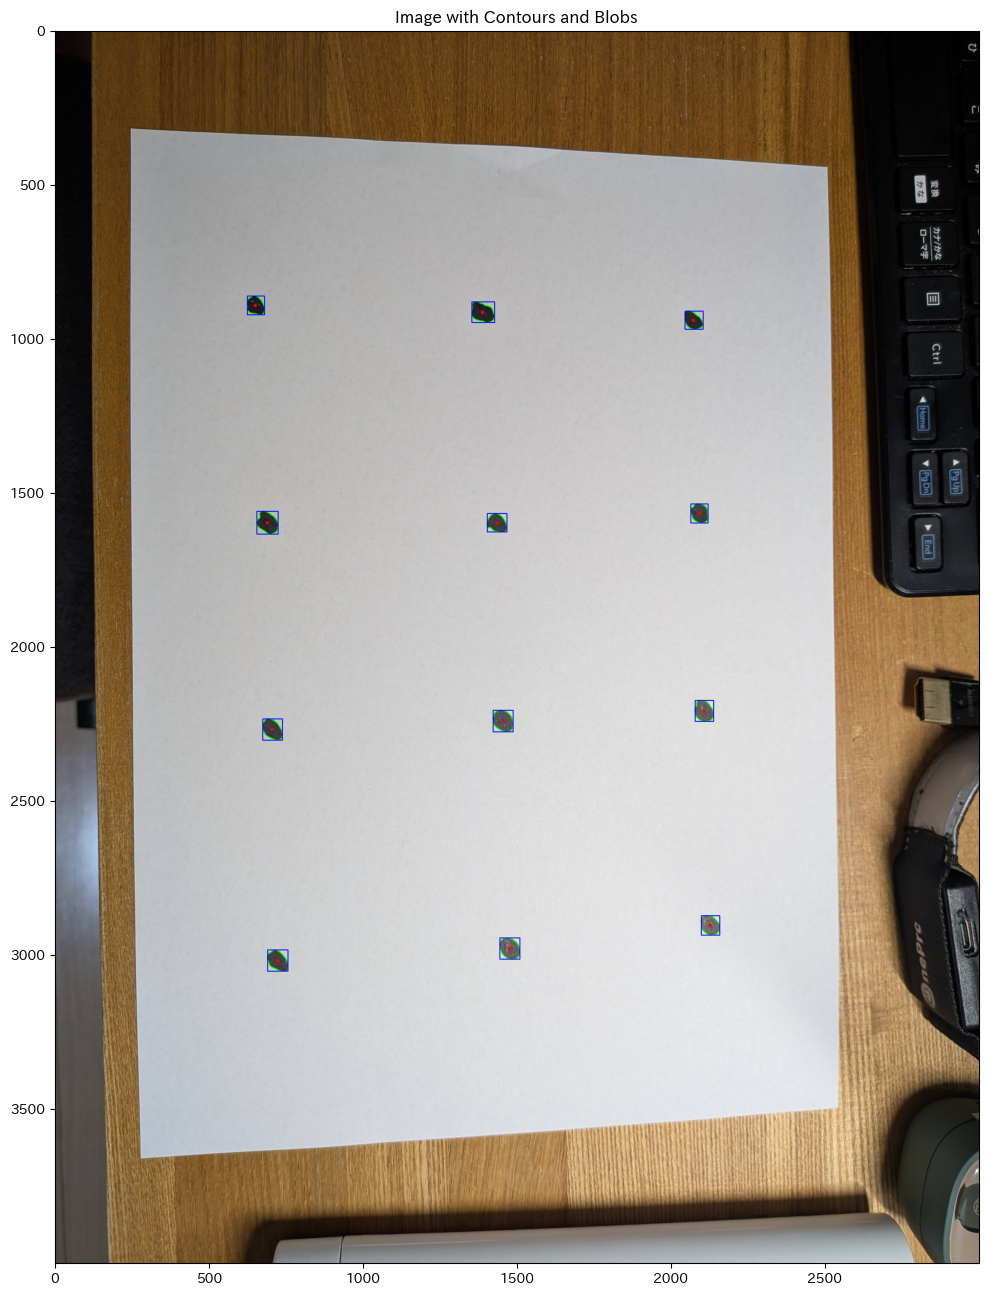

In [7]:
# 分析結果を描画するためにコピーを作成
image_with_analysis = image.copy()

# 切り出し領域リスト (x, y, width, height)
cropping_rect_list = [
    (460, 690, 400, 400),
    (1190, 700, 400, 400),
    (1880, 730, 400, 400),
    (490, 1400, 400, 400),
    (1230, 1390, 400, 400),
    (1890, 1370, 400, 400),
    (500, 2060, 400, 400),
    (1250, 2040, 400, 400),
    (1910, 2000, 400, 400),
    (520, 2820, 400, 400),
    (1280, 2780, 400, 400),
    (1930, 2700, 400, 400)
]

for left, top, width, height in cropping_rect_list:
    # 画像の切り出し
    cropped_image = crop_image(image, left, top, width, height)
    # 2値化
    binalized_image = binarize_image_with_otsu_algorithm(cropped_image)
    # 輪郭分析
    contours = analyze_contours(binalized_image)
    # ブロブ分析
    blob_stats, blob_centroids = analyze_blobs(binalized_image)
    # 輪郭を描画
    cv2.drawContours(image_with_analysis[top:top+height, left:left+width], contours, -1, (0, 255, 0), 2)
    # ブロブの外接矩形と重心を描画
    for stat, centroid in zip(blob_stats, blob_centroids):
        x, y, w, h, area = stat
        cx, cy = centroid
        cv2.rectangle(image_with_analysis[top:top+height, left:left+width], (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.circle(image_with_analysis[top:top+height, left:left+width], (int(cx), int(cy)), 5, (0, 0, 255), -1)

# 分析結果画像を表示
plt.figure(figsize=(20, 16)) 
plt.imshow(cv2.cvtColor(image_with_analysis, cv2.COLOR_BGR2RGB))
plt.title('Image with Contours and Blobs')
plt.show()